# Exploratory Data Analysis (EDA)

👀 Having a look at the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data import
file = "../data/feature_engineered_data.csv"
df_telco = pd.read_csv(file)

In [3]:
df_telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroups,IsMonthly,IsSingle,TotalServices,AvgMonthlyCharge,ChargeDiff
0,CUST00001,Male,0,0,1,3.0,1,Yes,No,0,...,Mailed check,68.61,205.83,Yes,0-1,1,0,0,68.61,0.000000e+00
1,CUST00002,Male,1,1,0,2.0,1,Yes,DSL,0,...,Bank transfer (automatic),23.15,46.30,No,0-1,0,0,1,23.15,0.000000e+00
2,CUST00003,Female,0,0,0,42.0,1,Yes,DSL,0,...,Electronic check,42.63,1790.46,Yes,2-4,1,0,3,42.63,0.000000e+00
3,CUST00004,Female,0,0,1,40.0,1,Yes,Fiber optic,0,...,Electronic check,75.04,3001.60,No,2-4,1,0,1,75.04,1.421085e-14
4,CUST00005,Male,1,1,1,17.0,1,Yes,Fiber optic,1,...,Electronic check,22.38,380.46,Yes,1-2,0,1,2,22.38,0.000000e+00


In [4]:
df_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66433 entries, 0 to 66432
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        66433 non-null  object 
 1   gender            66433 non-null  object 
 2   SeniorCitizen     66433 non-null  int64  
 3   Partner           66433 non-null  int64  
 4   Dependents        66433 non-null  int64  
 5   tenure            66433 non-null  float64
 6   PhoneService      66433 non-null  int64  
 7   MultipleLines     66433 non-null  object 
 8   InternetService   66433 non-null  object 
 9   OnlineSecurity    66433 non-null  int64  
 10  OnlineBackup      66433 non-null  int64  
 11  DeviceProtection  66433 non-null  int64  
 12  TechSupport       66433 non-null  int64  
 13  StreamingTV       66433 non-null  int64  
 14  StreamingMovies   66433 non-null  int64  
 15  Contract          66433 non-null  object 
 16  PaperlessBilling  66433 non-null  int64 

Converting int64 columns to int8 to save memory

In [5]:
def convert_from_int64_to_int8(df):
    """To convert int64 columns to int8"""
    df_copy = df.copy(deep=True)
    col_int64 = [col for col in df_copy.columns if df_copy[col].dtype == "int64"]
    
    for col in col_int64:
        df_copy[col] = df_copy[col].astype("int8")

    return df_copy


In [6]:
df_telco = convert_from_int64_to_int8(df_telco)

In [7]:
# Checking
df_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66433 entries, 0 to 66432
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        66433 non-null  object 
 1   gender            66433 non-null  object 
 2   SeniorCitizen     66433 non-null  int8   
 3   Partner           66433 non-null  int8   
 4   Dependents        66433 non-null  int8   
 5   tenure            66433 non-null  float64
 6   PhoneService      66433 non-null  int8   
 7   MultipleLines     66433 non-null  object 
 8   InternetService   66433 non-null  object 
 9   OnlineSecurity    66433 non-null  int8   
 10  OnlineBackup      66433 non-null  int8   
 11  DeviceProtection  66433 non-null  int8   
 12  TechSupport       66433 non-null  int8   
 13  StreamingTV       66433 non-null  int8   
 14  StreamingMovies   66433 non-null  int8   
 15  Contract          66433 non-null  object 
 16  PaperlessBilling  66433 non-null  int8  

In [8]:
# Checking specific column that may cause problems
df_telco["TotalServices"].value_counts()

TotalServices
0    26861
1    21173
2    13149
3     4360
4      801
5       83
6        6
Name: count, dtype: int64

Dropping the customerID column since it has no use 

In [9]:
df_telco.drop(columns=["customerID"], axis=1, inplace=True)

In [10]:
df_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66433 entries, 0 to 66432
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            66433 non-null  object 
 1   SeniorCitizen     66433 non-null  int8   
 2   Partner           66433 non-null  int8   
 3   Dependents        66433 non-null  int8   
 4   tenure            66433 non-null  float64
 5   PhoneService      66433 non-null  int8   
 6   MultipleLines     66433 non-null  object 
 7   InternetService   66433 non-null  object 
 8   OnlineSecurity    66433 non-null  int8   
 9   OnlineBackup      66433 non-null  int8   
 10  DeviceProtection  66433 non-null  int8   
 11  TechSupport       66433 non-null  int8   
 12  StreamingTV       66433 non-null  int8   
 13  StreamingMovies   66433 non-null  int8   
 14  Contract          66433 non-null  object 
 15  PaperlessBilling  66433 non-null  int8   
 16  PaymentMethod     66433 non-null  object

## Let's visualize our KPI (Churn)

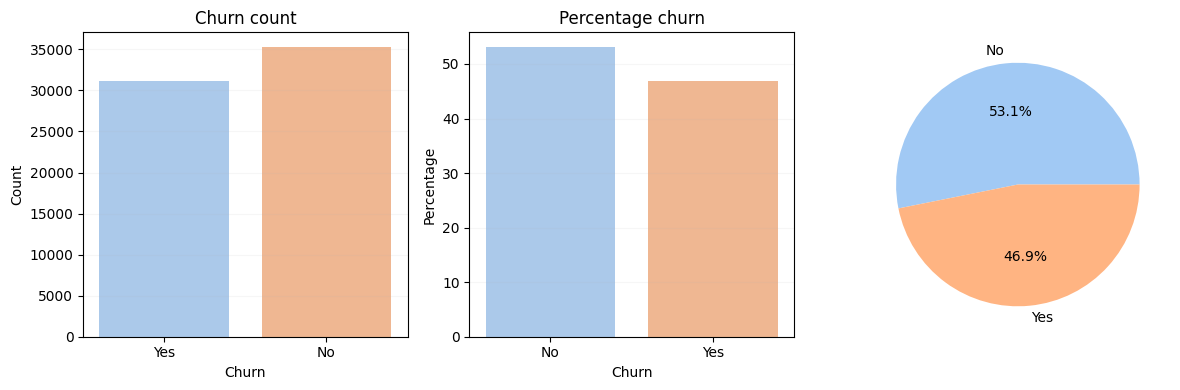

In [11]:
# Count bar chart
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.countplot(x="Churn", data=df_telco, palette="pastel", hue="Churn")
plt.title("Churn count")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.grid(True, axis="y", alpha=0.1)

# Bar plot for percentage churn
plt.subplot(1, 3, 2)
churn_pct = df_telco["Churn"].value_counts(normalize=True)*100
sns.barplot(x=churn_pct.index, y=churn_pct.values, palette="pastel", hue=churn_pct.index)
plt.title("Percentage churn")
plt.xlabel("Churn")
plt.ylabel("Percentage")
plt.grid(True, axis="y", alpha=0.1)

# Pie chart to show churn composition
plt.subplot(1, 3, 3)
plt.pie(df_telco["Churn"].value_counts(), labels=df_telco["Churn"].value_counts().index,
        colors=sns.color_palette("pastel"),
        autopct="%1.1f%%")

plt.tight_layout()
plt.show()

- From the chart we can see that up to almost 47% of the customers turn to churn
- This high churn rate turn take off much of the revenue of telco
- We need to investigate further inorder to identify the key factors causing this

## Churn Analysis by categorical variables

- Here I will simply analyze the KPI churn based on each categorical variable
- I will use bar charts to represent the numbers of churn and non churn within each category
- These will help me to see within each category which are the groups with higher or lower churn rates 

### I will start by converting int8 and object columns to categorical data type

In [12]:
def convert_int8_obj_to_cat(df):
    """Function to convert int8 and object variables to categorical type in a DataFrame"""
    df_copy = df.copy(deep=True)

    int8_obj_cols = [col for col in df_copy.columns if ((df_copy[col].dtype == 'int8') | (df_copy[col].dtype == 'object'))]

    for col in int8_obj_cols:
        df_copy[col] = df_copy[col].astype("category")

    return df_copy


In [13]:
df_telco = convert_int8_obj_to_cat(df_telco)

In [14]:
# Cchecking
df_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66433 entries, 0 to 66432
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            66433 non-null  category
 1   SeniorCitizen     66433 non-null  category
 2   Partner           66433 non-null  category
 3   Dependents        66433 non-null  category
 4   tenure            66433 non-null  float64 
 5   PhoneService      66433 non-null  category
 6   MultipleLines     66433 non-null  category
 7   InternetService   66433 non-null  category
 8   OnlineSecurity    66433 non-null  category
 9   OnlineBackup      66433 non-null  category
 10  DeviceProtection  66433 non-null  category
 11  TechSupport       66433 non-null  category
 12  StreamingTV       66433 non-null  category
 13  StreamingMovies   66433 non-null  category
 14  Contract          66433 non-null  category
 15  PaperlessBilling  66433 non-null  category
 16  PaymentMethod     6643

In [15]:
display(df_telco)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroups,IsMonthly,IsSingle,TotalServices,AvgMonthlyCharge,ChargeDiff
0,Male,0,0,1,3.0,1,Yes,No,0,0,...,Mailed check,68.61,205.83,Yes,0-1,1,0,0,68.61,0.000000e+00
1,Male,1,1,0,2.0,1,Yes,DSL,0,0,...,Bank transfer (automatic),23.15,46.30,No,0-1,0,0,1,23.15,0.000000e+00
2,Female,0,0,0,42.0,1,Yes,DSL,0,1,...,Electronic check,42.63,1790.46,Yes,2-4,1,0,3,42.63,0.000000e+00
3,Female,0,0,1,40.0,1,Yes,Fiber optic,0,0,...,Electronic check,75.04,3001.60,No,2-4,1,0,1,75.04,1.421085e-14
4,Male,1,1,1,17.0,1,Yes,Fiber optic,1,0,...,Electronic check,22.38,380.46,Yes,1-2,0,1,2,22.38,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66428,Male,1,1,1,30.0,1,Yes,Fiber optic,1,1,...,Electronic check,74.85,2245.50,No,2-4,0,1,3,74.85,0.000000e+00
66429,Male,0,1,0,15.0,1,Yes,Fiber optic,0,0,...,Bank transfer (automatic),40.67,610.05,Yes,1-2,1,0,0,40.67,7.105427e-15
66430,Male,0,0,0,20.0,1,No,DSL,1,0,...,Mailed check,29.44,588.80,No,1-2,1,0,1,29.44,3.552714e-15
66431,Male,0,0,0,21.0,1,No,Fiber optic,0,1,...,Electronic check,46.77,982.17,No,1-2,1,0,2,46.77,7.105427e-15


In [16]:
df_telco[df_telco.duplicated(keep=False)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroups,IsMonthly,IsSingle,TotalServices,AvgMonthlyCharge,ChargeDiff
30297,Female,0,0,0,12.0,1,Yes,DSL,0,0,...,Credit card (automatic),29.82,357.84,Yes,0-1,1,0,1,29.82,3.552714e-15
40353,Female,0,0,0,12.0,1,Yes,DSL,0,0,...,Credit card (automatic),29.82,357.84,Yes,0-1,1,0,1,29.82,3.552714e-15


Defining function to loop through the categorical columns and plotting bar charts with bars representing categories

In [17]:
def plot_kpi_analysis_charts(df, kpi: str):
    """Function to bar charts of each categorical variable with respect to kpi variable"""

    # Creating deep copy to make sure nothing happens to the original DataFrame
    df_copy = df.copy(deep=True)

    cat_cols = [col for col in df_copy.columns if df_copy[col].dtype == "category"]

    for col in cat_cols:
        print(f"\n📊 {kpi} by {col}")
        # Defining the pivot table
        pivot = pd.pivot_table(
            data=df_copy,
            index=col,
            columns=kpi,
            aggfunc="size",
            fill_value=0,
            observed=False
        )

        # Displaying the pivot table
        display(pivot)

        # Plotting the pivot table
        pivot.plot(kind="bar", stacked=False, figsize=(6, 5))
        plt.title(f"{kpi} by {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


Actually using the defined function


📊 Churn by gender


Churn,No,Yes
gender,,
Female,17890,15823
Male,17416,15304


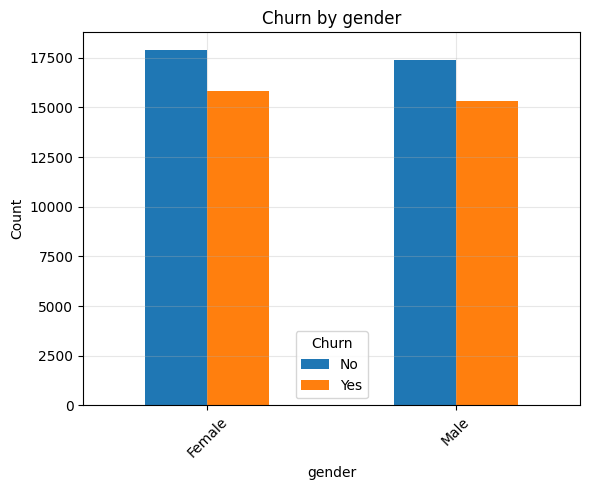


📊 Churn by SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
0,28210,25002
1,7096,6125


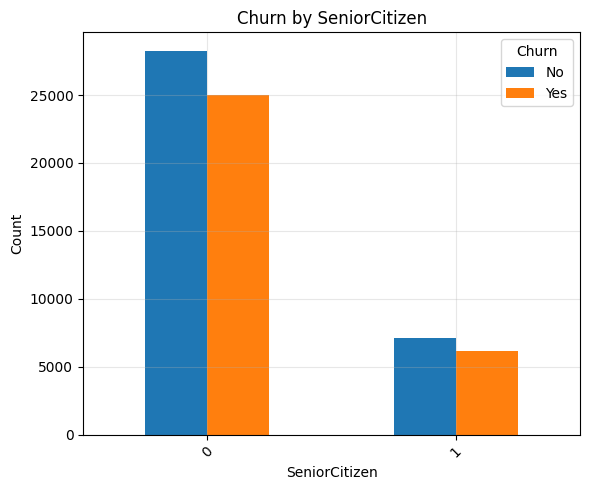


📊 Churn by Partner


Churn,No,Yes
Partner,,
0,21239,18475
1,14067,12652


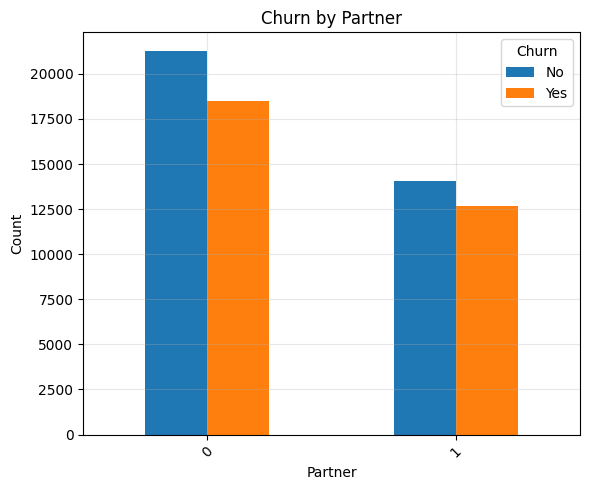


📊 Churn by Dependents


Churn,No,Yes
Dependents,,
0,24639,21806
1,10667,9321


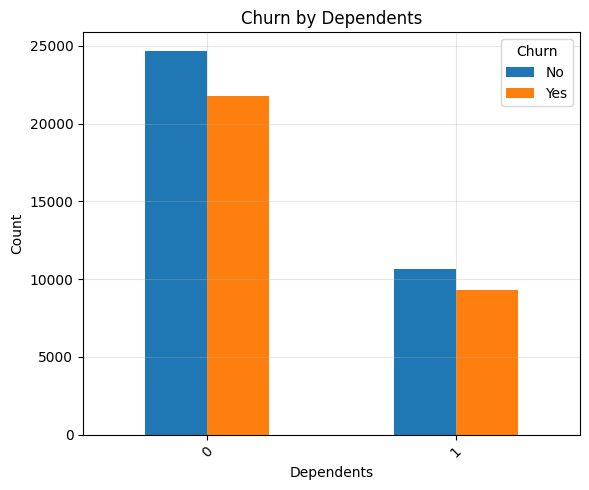


📊 Churn by PhoneService


Churn,No,Yes
PhoneService,,
0,3488,3128
1,31818,27999


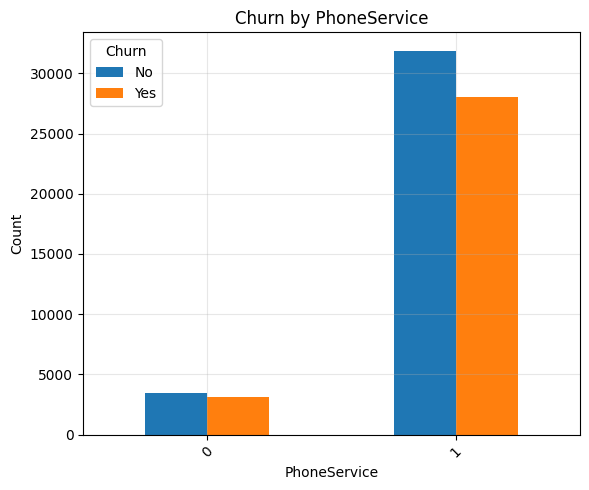


📊 Churn by MultipleLines


Churn,No,Yes
MultipleLines,,
No,12672,11204
No phone service,4128,3690
Yes,18506,16233


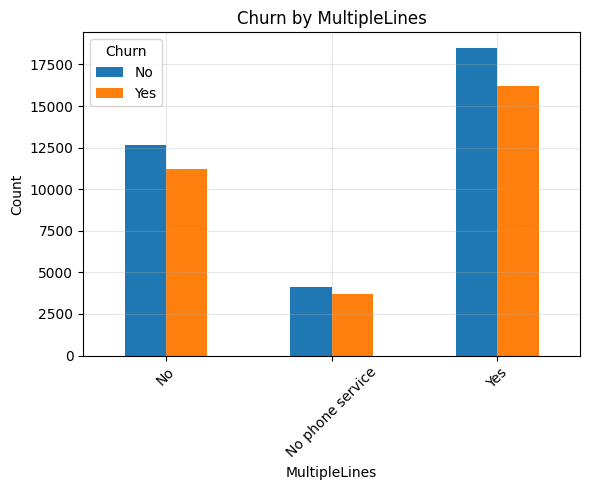


📊 Churn by InternetService


Churn,No,Yes
InternetService,,
DSL,8848,7866
Fiber optic,19485,17037
No,6973,6224


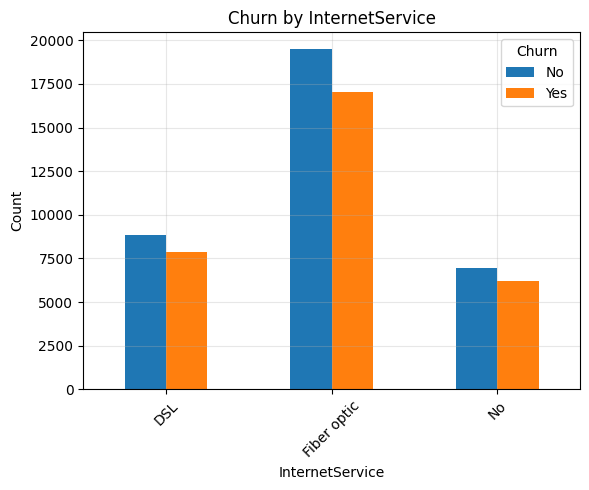


📊 Churn by OnlineSecurity


Churn,No,Yes
OnlineSecurity,,
0,29571,26235
1,5735,4892


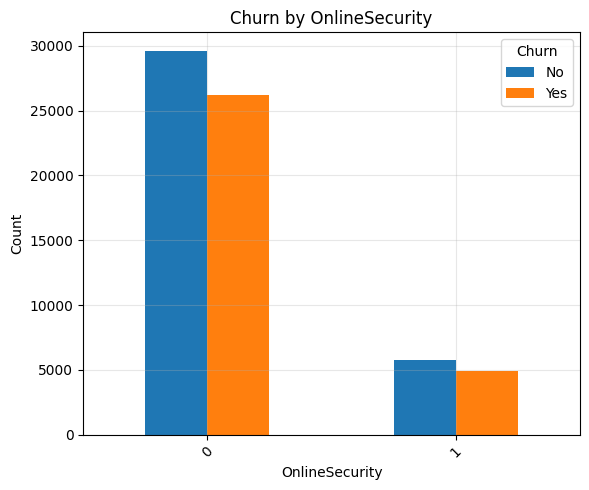


📊 Churn by OnlineBackup


Churn,No,Yes
OnlineBackup,,
0,29663,26076
1,5643,5051


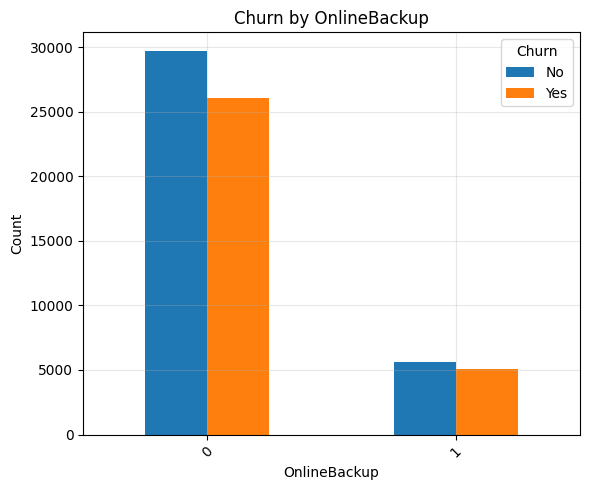


📊 Churn by DeviceProtection


Churn,No,Yes
DeviceProtection,,
0,29598,26125
1,5708,5002


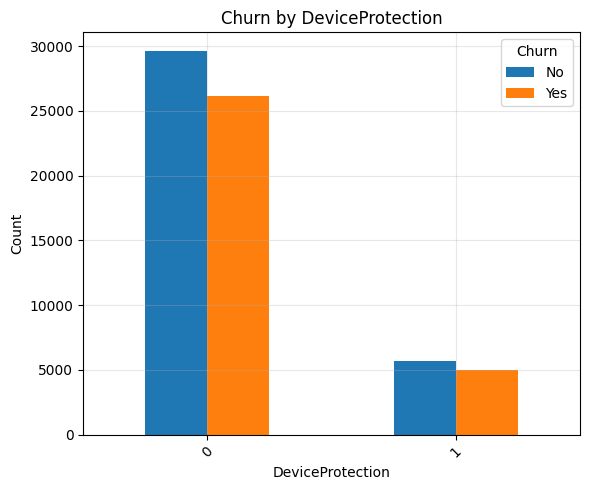


📊 Churn by TechSupport


Churn,No,Yes
TechSupport,,
0,29611,26170
1,5695,4957


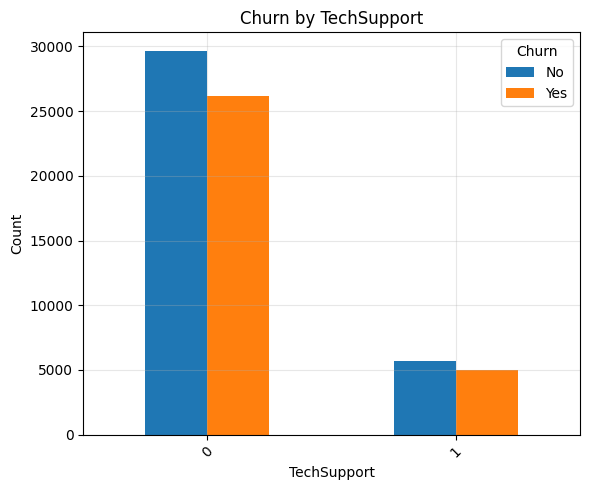


📊 Churn by StreamingTV


Churn,No,Yes
StreamingTV,,
0,29534,26090
1,5772,5037


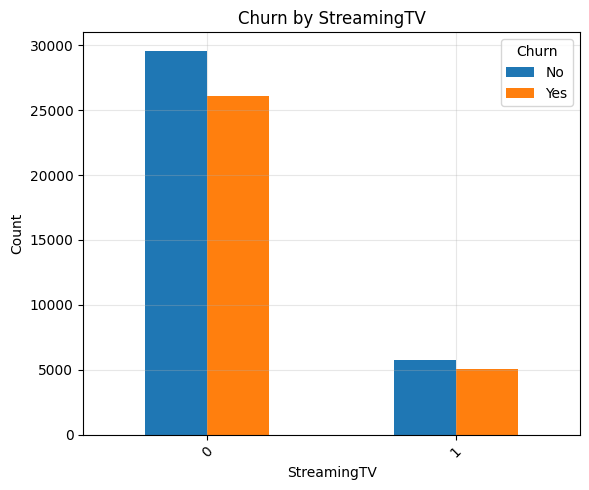


📊 Churn by StreamingMovies


Churn,No,Yes
StreamingMovies,,
0,29501,26218
1,5805,4909


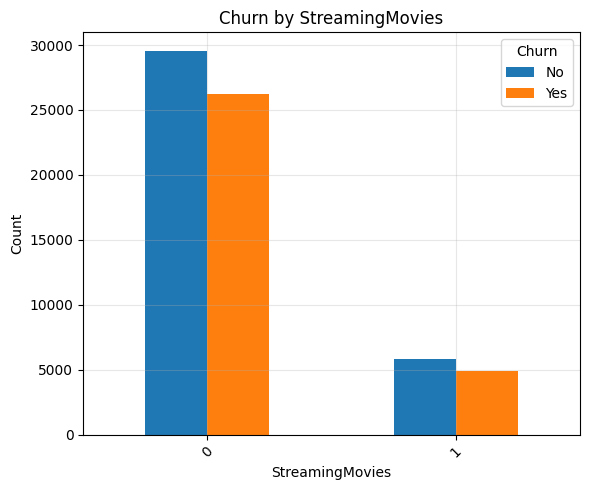


📊 Churn by Contract


Churn,No,Yes
Contract,,
Monthly,12054,27809
One year,10658,2644
Two year,12594,674


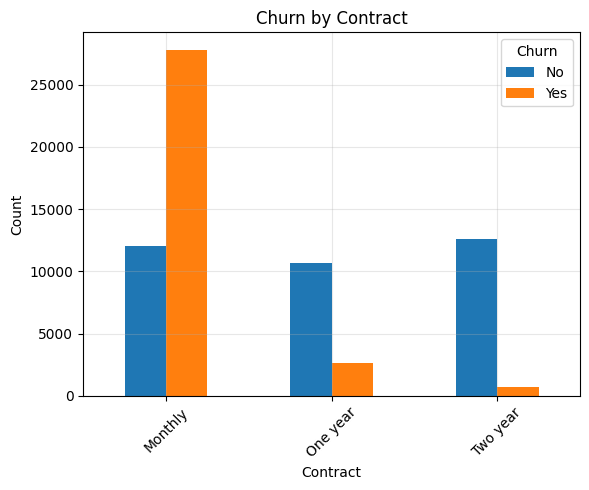


📊 Churn by PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
0,14140,12439
1,21166,18688


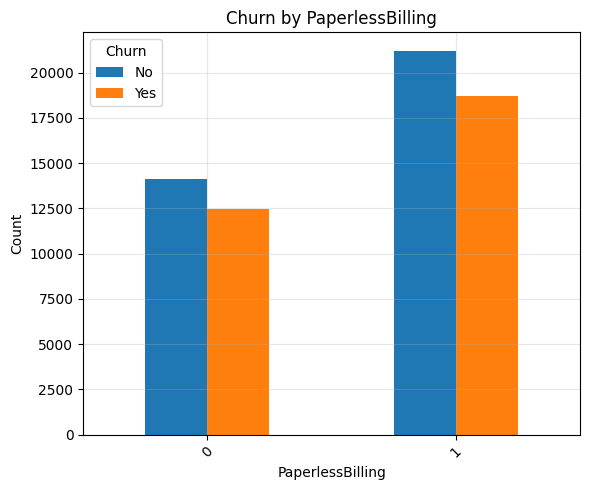


📊 Churn by PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),7133,6334
Credit card (automatic),5264,4575
Electronic check,15811,14047
Mailed check,7098,6171


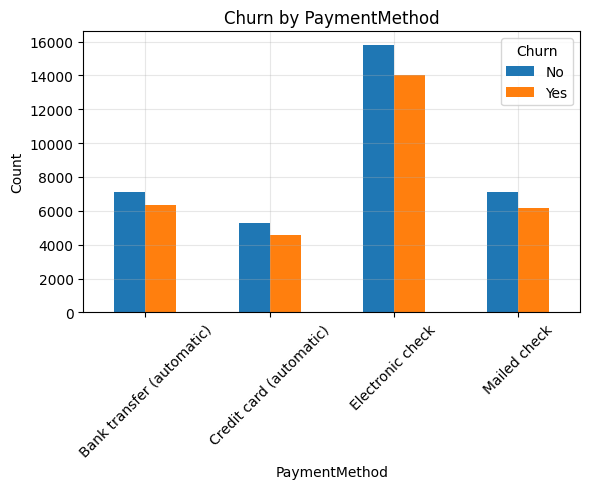


📊 Churn by Churn


Churn,No,Yes
Churn,,
No,35306,0
Yes,0,31127


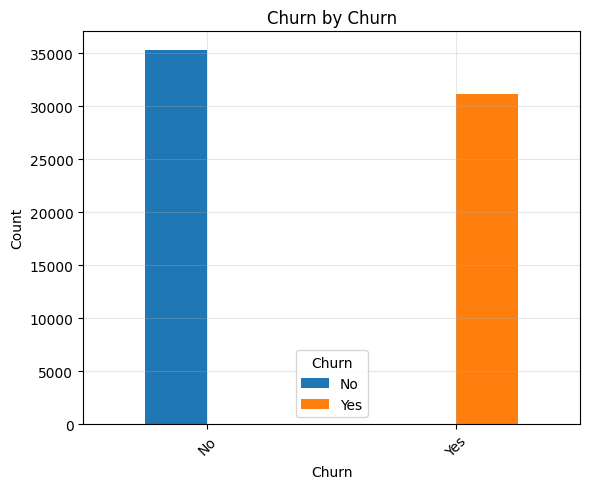


📊 Churn by TenureGroups


Churn,No,Yes
TenureGroups,,
0-1,10706,9433
1-2,10511,9423
2-4,12686,11093
4-6,1403,1178


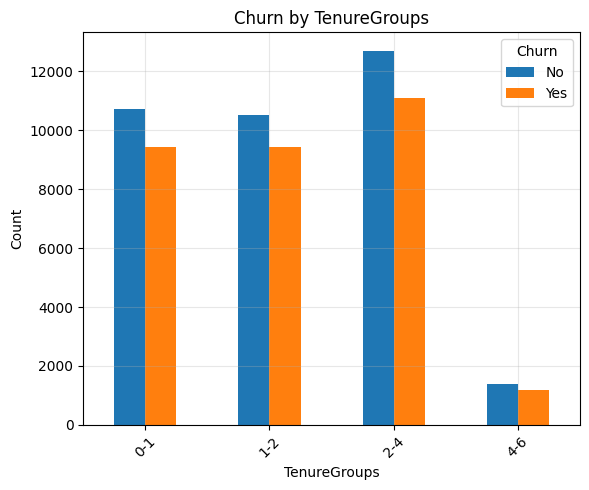


📊 Churn by IsMonthly


Churn,No,Yes
IsMonthly,,
0,23252,3318
1,12054,27809


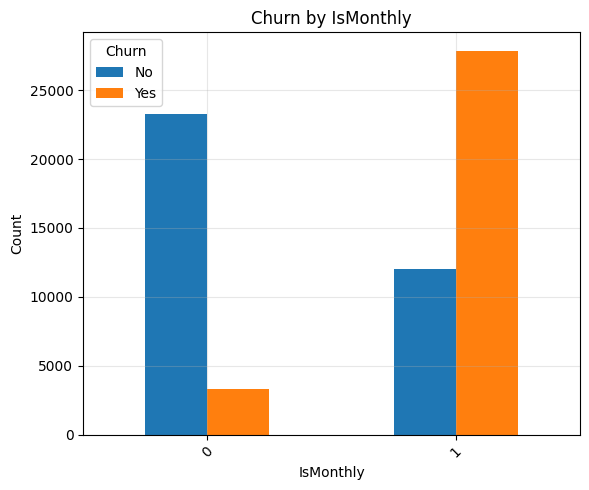


📊 Churn by IsSingle


Churn,No,Yes
IsSingle,,
0,31148,27354
1,4158,3773


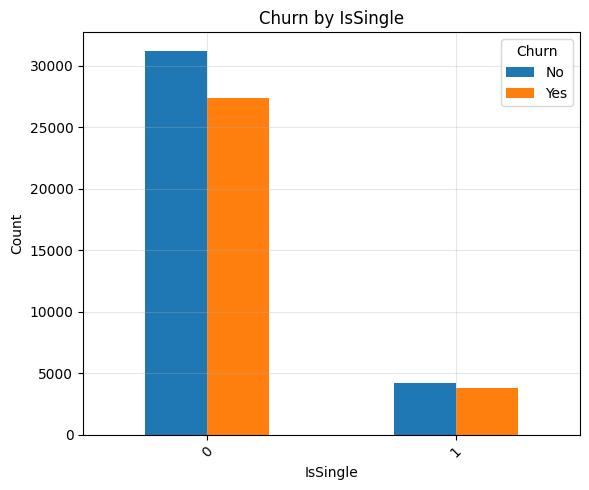


📊 Churn by TotalServices


Churn,No,Yes
TotalServices,,
0,14173,12688
1,11237,9936
2,7092,6057
3,2330,2030
4,425,376
5,47,36
6,2,4


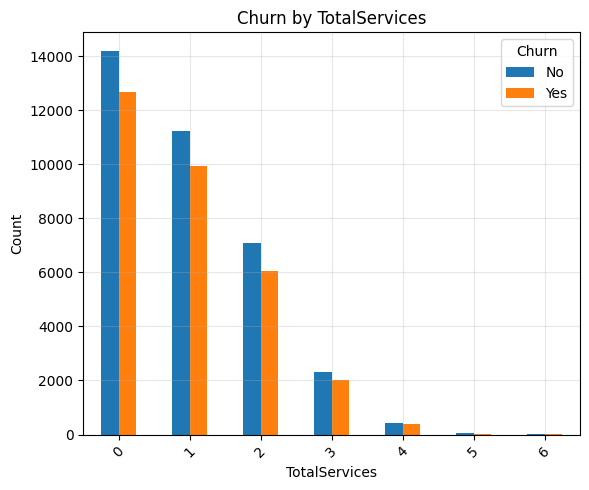

In [18]:
plot_kpi_analysis_charts(df_telco, "Churn")

- Based on the charts it can be seen that the contract type is the categorical variable that influence the most the number of churns
- Notably, customers on monthly contacts turn to churn higher than customers on other contract types

In [19]:
# df_telco.to_csv("/Users/igor_laminsi/Downloads/telco_eda.csv", index=False)

### Statistical relationship between categorical features and Churn

To identify which categorical feature are most related to churn, a statistical test (Chi-Square Test of Independence) was applied. This test evaluates whether there is a significant relationship between each feature and the churn outcome.

Features are ranked by their p-values, with smaller values indicating a stronger statistical association with churn. This analysis highlights which customer characteristics are most relevant for understanding and predicting churn behavior.

In [20]:
# Importing the required library
from scipy.stats import chi2_contingency

In [21]:
def chi2_test_kpi(df, kpi: str):
    """Returns a DataFrame that contains the the chi2 test rsult of each categorical feature w.r.t the kpi"""

    # Let's make a deep copy of the original DataFrame
    df_copy = df.copy(deep=True)

    # Let's start by retrieving all the categorical columns in df
    cat_cols = df_copy.select_dtypes(include=["category"]).columns

    # Defining empty list to store results
    results = []

    # Let's iterate through each retrieved feature to perform it chi2 test to measure statistical assiciation with KPI
    for col in cat_cols:
        # Skipping kpi feature itself
        if col != kpi:
            # Building the contingency table of observed values
            contingency_table = pd.crosstab(df_copy[col], df_copy[kpi])

            # Making sure we have atleast 2 rows and 2 columns in the contingency table
            if ((contingency_table.shape[0] > 1) & (contingency_table.shape[1] > 1)):
                # Retrieving test result for current feature
                chi2, p, dof, _ = chi2_contingency(contingency_table)

                # Appending outcome to results list
                results.append((col, chi2, p))

    # Sorting results by the p-value column
    results.sort(key=lambda x: x[2])

    return pd.DataFrame(results, columns=["Feature", "Chi2", "p-value"])


In [22]:
# Applying defined function to DataFrame to retrieve Chi2 tests of independence results
chi2_test_kpi(df_telco, "Churn")

,Feature,Chi2,p-value
0,Contract,21586.480103,0.000000
1,IsMonthly,21000.130814,0.000000
2,StreamingMovies,5.458281,0.019476
3,Partner,4.406409,0.035804
4,OnlineSecurity,3.385559,0.065770
5,IsSingle,1.832404,0.175844
6,SeniorCitizen,1.814025,0.178026
7,TenureGroups,3.314026,0.345695
8,TotalServices,6.414876,0.378354
9,OnlineBackup,0.710961,0.399125


- The test turn to reveal that Churn is strongly related to the Contract and IsMonthly categorical variable

## Churn Analysis by numeric variables

### Distribution of key Numeric variables by churn

I'm going to use KDE for each numerical variable vs churn to see if there are patterns between churners and non churners

In [23]:
df_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66433 entries, 0 to 66432
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            66433 non-null  category
 1   SeniorCitizen     66433 non-null  category
 2   Partner           66433 non-null  category
 3   Dependents        66433 non-null  category
 4   tenure            66433 non-null  float64 
 5   PhoneService      66433 non-null  category
 6   MultipleLines     66433 non-null  category
 7   InternetService   66433 non-null  category
 8   OnlineSecurity    66433 non-null  category
 9   OnlineBackup      66433 non-null  category
 10  DeviceProtection  66433 non-null  category
 11  TechSupport       66433 non-null  category
 12  StreamingTV       66433 non-null  category
 13  StreamingMovies   66433 non-null  category
 14  Contract          66433 non-null  category
 15  PaperlessBilling  66433 non-null  category
 16  PaymentMethod     6643

In [24]:
# Selecting numerical columns
num_cols = df_telco.select_dtypes("float").columns

num_cols

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge',
       'ChargeDiff'],
      dtype='object')

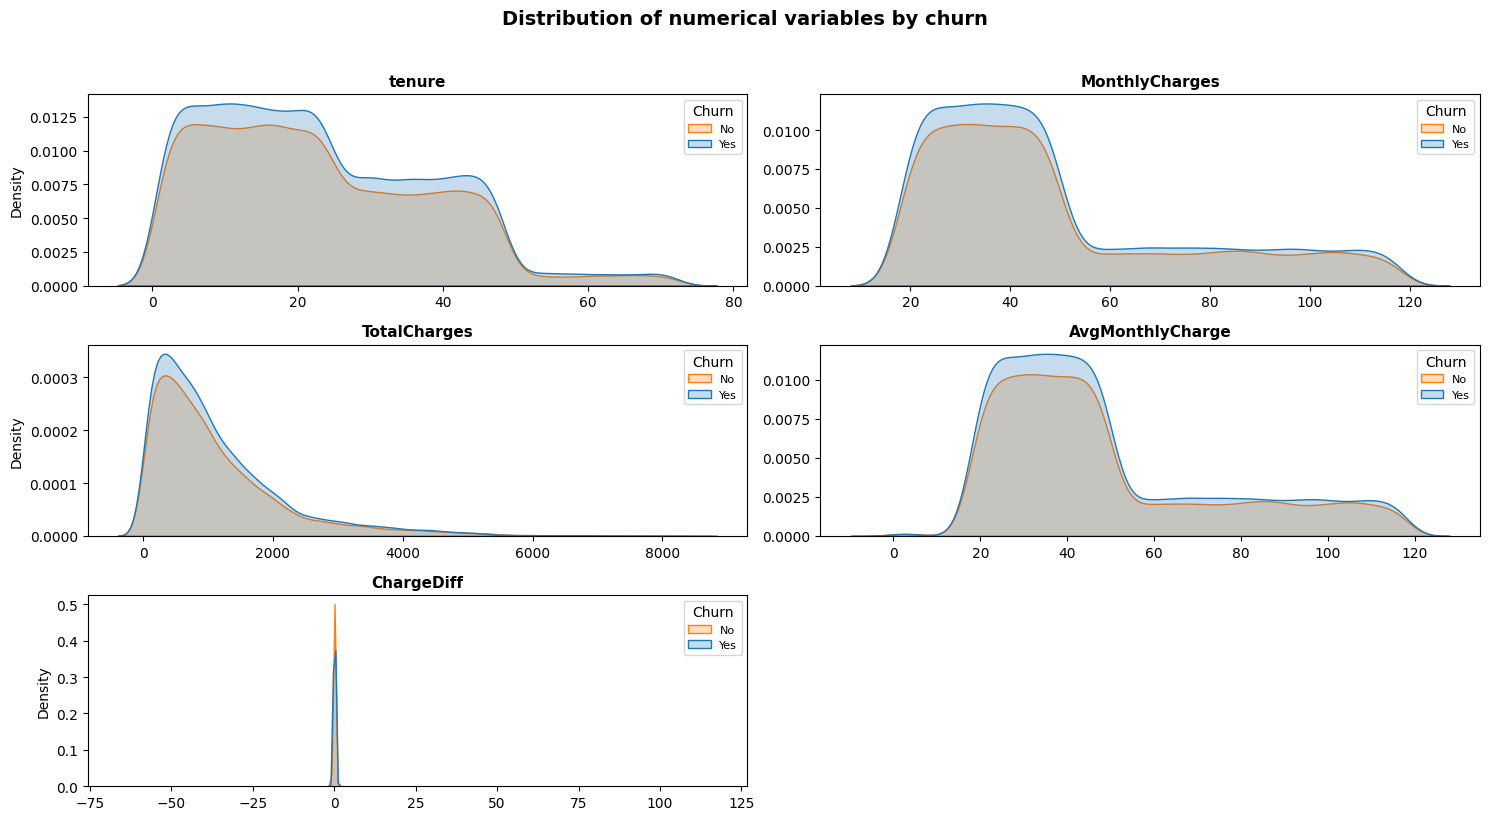

In [25]:
# Intialising figure and subplots for kde charts
figure, axes = plt.subplots(3, 2, figsize=(15, 8))

# Setting figure general title
figure.suptitle("Distribution of numerical variables by churn", fontsize=14, fontweight="bold", y=1.02)

# Looping through numerical columns and subplot slots to generate kde charts
for ax, col in zip(axes.flatten(), num_cols):
    sns.kdeplot(data=df_telco, x=col, hue="Churn", fill=True, ax=ax)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Density" if ((ax == axes[0, 0]) | (ax == axes[1, 0]) | (ax == axes[2, 0])) else "")
    ax.legend(title="Churn", labels=["No", "Yes"], fontsize=8)

axes[2, 1].set_visible(False)
plt.tight_layout()
plt.show()

- From the KDE plots we can see no major difference for the distribution of numerical variables for churners and non churners

### Statistical Analysis of the Numerical features and their relationship with Churn

- Here let's first verify which numerical respects normality to apply t test
- I'm going to apply is the **Kolmogorov-Smirnov** test of normality since we have more than 5000 observations

Below, i'm looping through the numerical columns splitting it into the 2 churn groups to determine whether normality is respected

In [26]:
# Importing the statistics library
from scipy import stats

In [27]:
results = []

for col in num_cols:
    # Retrieving the groups
    for group_n in df_telco["Churn"].unique():
        group_s = df_telco[df_telco["Churn"] == group_n][col]

        # Retrieving the normality test statistic and p-value for each group
        D_stat, p_value = stats.kstest(group_s, "norm", args=(group_s.mean(), group_s.std()))

        # Appending to result
        results.append((col, group_n, D_stat, p_value))

# Converting results to DataFrame
df_results = pd.DataFrame(results, columns=["Num Feature", "Churn", "D stat", "p value"])

# Formatting p value column of df_results
df_results.style.format({"p value": ":.10f"})

# Displaying results
display(df_results)

,Num Feature,Churn,D stat,p value
0,tenure,Yes,0.080427,1.375979e-175
1,tenure,No,0.079827,3.839130e-196
2,MonthlyCharges,Yes,0.185540,0.000000e+00
3,MonthlyCharges,No,0.183779,0.000000e+00
4,TotalCharges,Yes,0.146707,0.000000e+00
5,TotalCharges,No,0.145327,0.000000e+00
6,AvgMonthlyCharge,Yes,0.184586,0.000000e+00
7,AvgMonthlyCharge,No,0.182680,0.000000e+00
8,ChargeDiff,Yes,0.514900,0.000000e+00
9,ChargeDiff,No,0.515229,0.000000e+00


- The test shows that none of the churn groups within the numerical features are normally distributed
- Now I need to take log of the values in those columns to see if churn groups within numerical columns follow a normal distribution

In [28]:
results = []

for col in num_cols:
    # Retrieving the groups
    for group_n in df_telco["Churn"].unique():
        log_group_s = np.log(df_telco[df_telco["Churn"] == group_n][col])

        # Retrieving the normality test values for each group
        D_stat, p_value = stats.kstest(log_group_s, "norm", args=(log_group_s.mean(), log_group_s.std()))

        # Appending to result
        results.append((col, group_n, D_stat, p_value))

# Converting results to DataFrame
df_results_l = pd.DataFrame(results, columns=["Log Num Feature", "Churn", "Shapiro stat", "p value"])

# Formatting p value column of df_results
df_results_l.style.format({"p value": ":.10f"})

# Displaying results
display(df_results_l)

/Users/igor_laminsi/Documents/data_science_portfolio_projects/telcoconnect-churn/venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/igor_laminsi/Documents/data_science_portfolio_projects/telcoconnect-churn/venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/igor_laminsi/Documents/data_science_portfolio_projects/telcoconnect-churn/venv/lib/python3.9/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Log Num Feature,Churn,Shapiro stat,p value
0,tenure,Yes,0.104477,2.731370e-296
1,tenure,No,0.103864,0.000000e+00
2,MonthlyCharges,Yes,0.082659,1.863967e-185
3,MonthlyCharges,No,0.081075,2.569849e-202
4,TotalCharges,Yes,0.058004,1.796513e-91
5,TotalCharges,No,0.060146,1.816405e-111
6,AvgMonthlyCharge,Yes,0.083318,1.999655e-188
7,AvgMonthlyCharge,No,0.081561,9.488411e-205
8,ChargeDiff,Yes,NaN,NaN
9,ChargeDiff,No,NaN,NaN


- Here the p values are still < 0.05, so the null hypothesis is rejected meaning the log the numerical features still violates normality
- Definitely, parametric statistical tests such as t-test can't be used to measure the influence of churn on the numerical feautres

### Mann-Whitney U Test

Here I'm going to perform the Mann-Whitney U Test which is a non-parametric test that would enable me determine whether the churn groups across the different numerical variables are identical

In [29]:
# Initiazing variable to store the test result
results = []

# Looping through the different numerical features
for col in num_cols:
        churn_group = df_telco[df_telco["Churn"] == "Yes"][col]
        no_chrun_group = df_telco[df_telco["Churn"] == "No"][col]

        # Executing the Mann-Whitney U test
        U_stat, p_value = stats.mannwhitneyu(churn_group, no_chrun_group)

        # Appending test outcome to results list
        results.append((col, U_stat, p_value))

# Sorting results by p value
results.sort(key= lambda x: x[2])

# Converting to datafrmae
df_mann_whitney_U_res = pd.DataFrame(results, columns=["Feature", "U Statistic", "p value"])


# Display
display(df_mann_whitney_U_res)

,Feature,U Statistic,p value
0,tenure,546718878.0,0.262005
1,ChargeDiff,550987804.5,0.393956
2,TotalCharges,547554651.0,0.433880
3,MonthlyCharges,549373171.5,0.963861
4,AvgMonthlyCharge,549521565.0,0.988150


- From the results since P value > 0,05, I can conclude that all the numerical features does not significantly differ between churners and non churners
- This confirms the insight given by the KDE plots

In [30]:
df_telco["PaymentMethod"].unique()

['Mailed check', 'Bank transfer (automatic)', 'Electronic check', 'Credit card (automatic)']
Categories (4, object): ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']